# 01 — Analyse Exploratoire (EDA)

**Projet : ObRail — Détection des sous-dessertes ferroviaires**

**Objectif** : explorer le jeu de données enrichi pour comprendre sa structure, valider sa qualité, et **vérifier si les features permettent de prédire la cible `is_underserved`** (ligne sous-desservie : demande > offre) *avant* la phase de modélisation.

- **Input** : `../data/processed/routes_processed.csv`
- **Outputs** : observations documentées + figures dans `../evaluation/plots/`
- **Type de problème** : classification binaire (`is_underserved` ∈ {0,1}), classes déséquilibrées
- **Date** : 2026

## §1 — Setup & imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')

PLOTS_DIR = Path('../evaluation/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print('Setup OK')

Setup OK


## §2 — Chargement des données

In [2]:
df = pd.read_csv('../data/processed/routes_processed.csv')
print('Dimensions :', df.shape)

Dimensions : (3678, 29)


## §3 — Aperçu général

In [3]:
df.head()

,route_name,origin,destination,service_type,route_name_simple,origin_country,destination_country,distance_km,operator,type,train_gco2_pkm,plane_gco2_pkm,train_co2_kg,plane_co2_kg,co2_savings_kg,savings_percent,emission_source,calculation_date,is_cross_border,distance_category,type_encoded,co2_ratio_train_plane,capacity,load_factor,passengers_estimated,train_co2_per_passenger,plane_co2_per_passenger,service_ratio,is_underserved
0,ICE 18,Hauptbahnhof,Berlin Gesundbrunnen,day,→ Berlin Gesundbrunnen,DE,DE,238.64,DB,day,14,144,3.34,34.36,31.02,90.28,Back-on-Track 2022,2026-03-22,0,moyen,0,0.0972,500,0.674836,337,0.0099,0.1020,0.674,0
1,IC 51,Hauptbahnhof,Dortmund Hbf,day,→ Dortmund,DE,DE,256.33,DB,day,14,144,3.59,36.91,33.32,90.27,Back-on-Track 2022,2026-03-22,0,moyen,0,0.0973,500,0.643087,321,0.0112,0.1150,0.642,0
2,ICE 28,Hamburg Altona S,Hauptbahnhof,day,Hamburg Altona S →,DE,DE,296.60,DB,day,14,144,4.15,42.71,38.56,90.28,Back-on-Track 2022,2026-03-22,0,moyen,0,0.0972,500,0.682384,341,0.0122,0.1252,0.682,0
3,IC 51,Hauptbahnhof,Koln Hbf,day,→ Koln,DE,DE,285.66,DB,day,14,144,4.00,41.14,37.14,90.28,Back-on-Track 2022,2026-03-22,0,moyen,0,0.0972,500,0.726151,363,0.0110,0.1133,0.726,0
4,ICE 11,Munchen Hbf,Hauptbahnhof,day,Munchen →,DE,DE,317.10,DB,day,14,144,4.44,45.66,41.22,90.28,Back-on-Track 2022,2026-03-22,0,moyen,0,0.0972,500,0.638292,319,0.0139,0.1431,0.638,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3678 entries, 0 to 3677
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   route_name               3678 non-null   object 
 1   origin                   3678 non-null   object 
 2   destination              3678 non-null   object 
 3   service_type             3678 non-null   object 
 4   route_name_simple        3678 non-null   object 
 5   origin_country           3678 non-null   object 
 6   destination_country      3678 non-null   object 
 7   distance_km              3678 non-null   float64
 8   operator                 3678 non-null   object 
 9   type                     3678 non-null   object 
 10  train_gco2_pkm           3678 non-null   int64  
 11  plane_gco2_pkm           3678 non-null   int64  
 12  train_co2_kg             3678 non-null   float64
 13  plane_co2_kg             3678 non-null   float64
 14  co2_savings_kg          

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
distance_km,3678.0,176.512545,203.015246,10.050000,35.535000,81.905000,256.925000,2482.420000
train_gco2_pkm,3678.0,14.000000,0.000000,14.000000,14.000000,14.000000,14.000000,14.000000
plane_gco2_pkm,3678.0,144.000000,0.000000,144.000000,144.000000,144.000000,144.000000,144.000000
train_co2_kg,3678.0,2.471276,2.842274,0.140000,0.500000,1.146670,3.600000,34.750000
plane_co2_kg,3678.0,25.417851,29.234187,1.450000,5.120000,11.794320,36.995000,357.470000
co2_savings_kg,3678.0,22.946575,26.391915,1.310000,4.620000,10.647650,33.395000,322.720000
savings_percent,3678.0,90.277072,0.057884,89.930000,90.260000,90.280000,90.290000,90.600000
is_cross_border,3678.0,0.021479,0.144995,0.000000,0.000000,0.000000,0.000000,1.000000
type_encoded,3678.0,0.184883,0.388255,0.000000,0.000000,0.000000,0.000000,1.000000
co2_ratio_train_plane,3678.0,0.097229,0.000579,0.094000,0.097100,0.097200,0.097400,0.100700


## §4 — Qualité des données

In [6]:
print('Valeurs manquantes par colonne (>0) :')
na = df.isnull().sum()
print(na[na > 0] if (na > 0).any() else 'Aucune valeur manquante')
print('\nLignes dupliquées :', df.duplicated().sum())

Valeurs manquantes par colonne (>0) :
Aucune valeur manquante

Lignes dupliquées : 0


In [7]:
# Bornes des features clés (détection de valeurs aberrantes)
for c in ['distance_km','load_factor','capacity','passengers_estimated','service_ratio']:
    print(f'{c:22s} min={df[c].min():.3f}  max={df[c].max():.3f}')

# Features à variance nulle (inutiles pour le modèle)
const_cols = [c for c in df.select_dtypes('number').columns if df[c].nunique() == 1]
print('\nFeatures constantes (variance nulle) :', const_cols)

distance_km            min=10.050  max=2482.420
load_factor            min=0.449  max=0.882
capacity               min=400.000  max=500.000
passengers_estimated   min=179.000  max=440.000
service_ratio          min=0.448  max=0.880

Features constantes (variance nulle) : ['train_gco2_pkm', 'plane_gco2_pkm']


**Déduction §4** : données **propres** (0 valeur manquante, 0 doublon).
Plusieurs colonnes liées aux émissions sont **constantes ou quasi-constantes** (`train_gco2_pkm`=14, `plane_gco2_pkm`=144, `savings_percent`≈90 %, `co2_ratio_train_plane`≈0,097) — vestiges de l'ancien sujet « CO₂ », **sans valeur prédictive** pour la sous-desserte.

## §5 — Analyse de la cible `is_underserved` ⭐

                effectif  part_%
is_underserved                  
0                   3296   89.61
1                    382   10.39


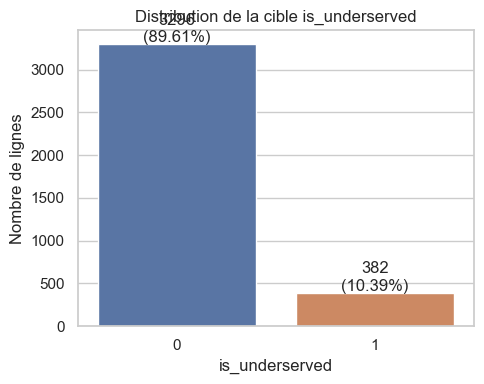

In [8]:
counts = df['is_underserved'].value_counts()
pct = (df['is_underserved'].value_counts(normalize=True) * 100).round(2)
print(pd.DataFrame({'effectif': counts, 'part_%': pct}))

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, legend=False, ax=ax, palette=['#4c72b0', '#dd8452'])
ax.set_title("Distribution de la cible is_underserved")
ax.set_xlabel('is_underserved'); ax.set_ylabel('Nombre de lignes')
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, f'{v}\n({pct.iloc[i]}%)', ha='center')
plt.tight_layout(); plt.savefig(PLOTS_DIR / 'eda_target_balance.png', dpi=110); plt.show()

**Déduction §5** : forte **asymétrie de classes** — ≈ **89,6 % de `0`** contre **10,4 % de `1`**.
Conséquences pour l'évaluation :
- l'**accuracy est trompeuse** : un modèle prédisant toujours `0` atteint déjà ~89,6 % ;
- privilégier **precision / recall / F1** sur la classe positive, **ROC-AUC** et surtout **PR-AUC** ;
- prévoir un **rééquilibrage** (oversampling/SMOTE) à l'entraînement.

## §6 — Analyse univariée des features

In [9]:
# Variables catégorielles
for c in ['service_type','type','distance_category','is_cross_border']:
    print(f'-- {c} --'); print(df[c].value_counts(), '\n')
print('-- top 8 opérateurs --'); print(df['operator'].value_counts().head(8))
print('\nPays origine / destination distincts :', df['origin_country'].nunique(), '/', df['destination_country'].nunique())
print('service_type identique à type ?', (df['service_type'] == df['type']).all())

-- service_type --
service_type
day      2998
night     680
Name: count, dtype: int64 

-- type --
type
day      2998
night     680
Name: count, dtype: int64 

-- distance_category --
distance_category
court        2386
moyen         708
long          559
tres_long      25
Name: count, dtype: int64 

-- is_cross_border --
is_cross_border
0    3599
1      79
Name: count, dtype: int64 

-- top 8 opérateurs --
operator
SNCF                                                    1333
DB                                                       590
SBB (Schweizerische Bundesbahnen SBB)                    433
ÖBB                                                      188
SNCF VOYAGEURS                                           182
SNCF (Société Nationale des Chemins de fer Français)     139
DB Regio (DB Regio AG Baden-Württemberg)                  95
BLS-bls (BLS AG (bls))                                    73
Name: count, dtype: int64



Pays origine / destination distincts : 21 / 21
service_type identique à type ? True


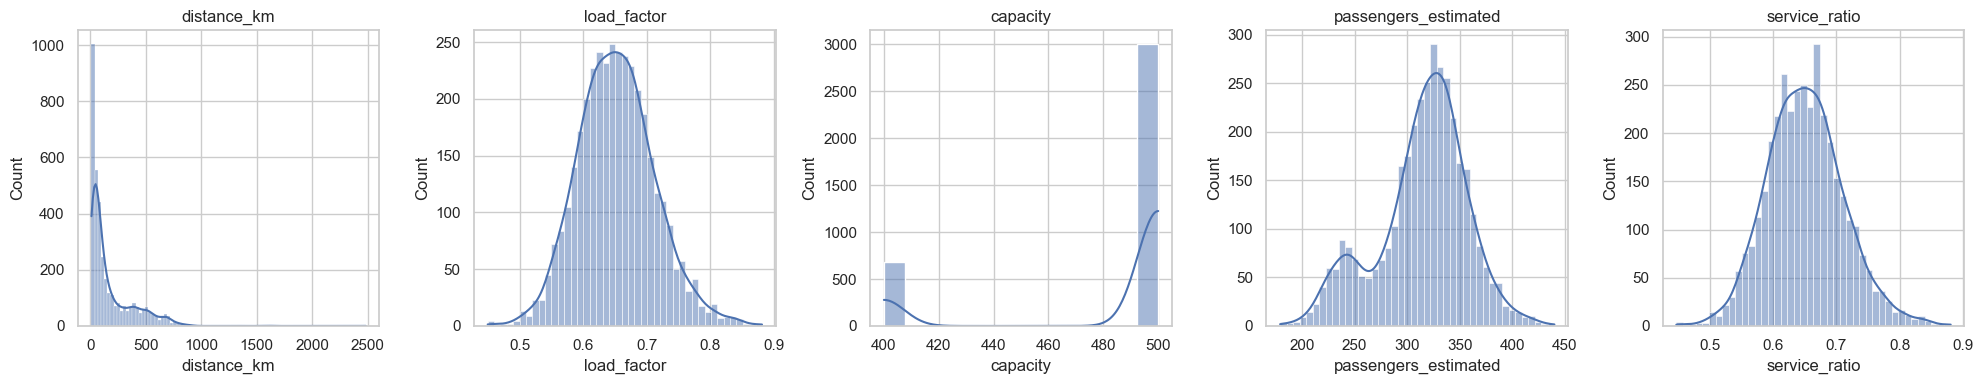

In [10]:
# Distributions des features numériques
num_feats = ['distance_km','load_factor','capacity','passengers_estimated','service_ratio']
fig, axes = plt.subplots(1, len(num_feats), figsize=(20, 4))
for ax, c in zip(axes, num_feats):
    sns.histplot(df[c], kde=True, ax=ax, color='#4c72b0')
    ax.set_title(c)
plt.tight_layout(); plt.savefig(PLOTS_DIR / 'eda_distributions.png', dpi=110); plt.show()

**Déduction §6** : `service_type` et `type` sont **strictement identiques** (colonne dupliquée → en supprimer une).
`distance_km` est très asymétrique (longue traîne) ; `capacity` est quasi-binaire (≈400/500) ; `is_cross_border` est rare (79 lignes).

## §7 — Features vs cible `is_underserved` ⭐

In [11]:
num = ['distance_km','load_factor','capacity','passengers_estimated','service_ratio','is_cross_border']
print('Moyenne des features par classe :')
print(df.groupby('is_underserved')[num].mean().T)
print('\nCorrélation des features avec la cible :')
print(df[num + ['is_underserved']].corr()['is_underserved'].drop('is_underserved').sort_values())

Moyenne des features par classe :
is_underserved                 0           1
distance_km           173.730451  200.517212
load_factor             0.651932    0.654252
capacity              481.644417  480.366492
passengers_estimated  314.131978  314.356021
service_ratio           0.650873    0.653194
is_cross_border         0.019721    0.036649

Corrélation des features avec la cible :
capacity               -0.010043
passengers_estimated    0.001604
service_ratio           0.011726
load_factor             0.011727
is_cross_border         0.035623
distance_km             0.040259
Name: is_underserved, dtype: float64


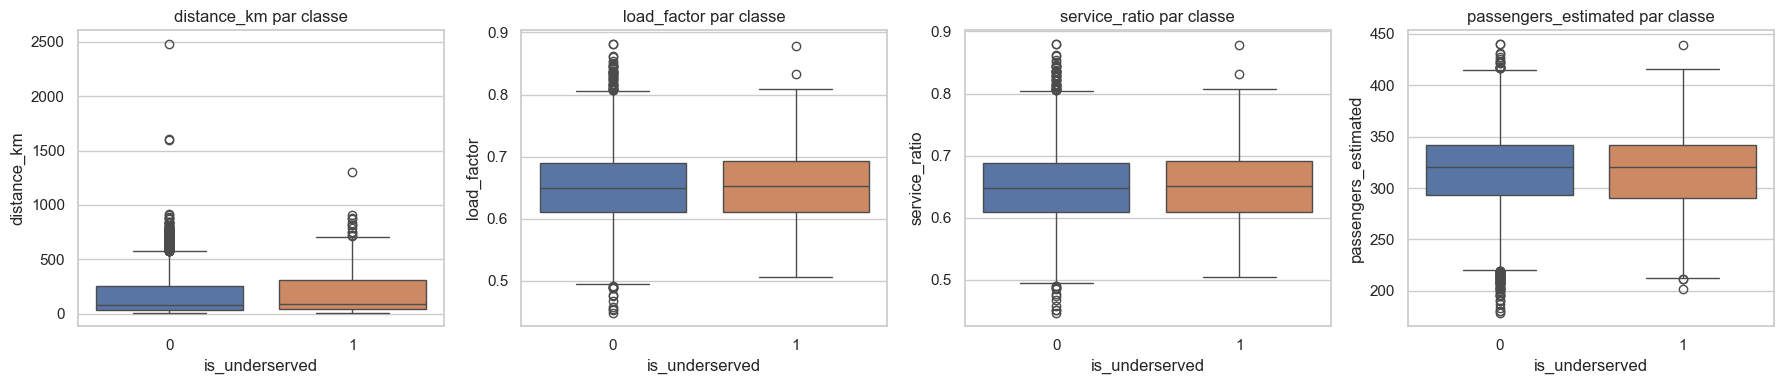

In [12]:
# Boxplots des features numériques selon la classe
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, ['distance_km','load_factor','service_ratio','passengers_estimated']):
    sns.boxplot(data=df, x='is_underserved', y=c, hue='is_underserved', legend=False, ax=ax, palette=['#4c72b0', '#dd8452'])
    ax.set_title(f'{c} par classe')
plt.tight_layout(); plt.savefig(PLOTS_DIR / 'eda_features_vs_target.png', dpi=110); plt.show()

In [13]:
# Test de fuite de cible : is_underserved est-il un simple seuil sur service_ratio / load_factor ?
for c in ['service_ratio','load_factor']:
    g0 = df.loc[df.is_underserved == 0, c]; g1 = df.loc[df.is_underserved == 1, c]
    chevauche = g1.max() > g0.min() and g0.max() > g1.min()
    print(f'{c}: classe0 [{g0.min():.3f}, {g0.max():.3f}]  classe1 [{g1.min():.3f}, {g1.max():.3f}]  -> chevauchement: {chevauche}')

service_ratio: classe0 [0.448, 0.880]  classe1 [0.505, 0.878]  -> chevauchement: True
load_factor: classe0 [0.449, 0.882]  classe1 [0.506, 0.878]  -> chevauchement: True


In [14]:
# Taux de sous-desserte par variable catégorielle / géographique
print('Par distance_category :'); print((df.groupby('distance_category')['is_underserved'].mean()*100).round(1))
top = df['origin_country'].value_counts().head(10).index
print('\nPar pays origine (top 10 volume) :'); print((df[df.origin_country.isin(top)].groupby('origin_country')['is_underserved'].mean()*100).round(1).sort_values(ascending=False))
topop = df['operator'].value_counts().head(10).index
print('\nPar opérateur (top 10 volume) :'); print((df[df.operator.isin(topop)].groupby('operator')['is_underserved'].mean()*100).round(1).sort_values(ascending=False))

Par distance_category :
distance_category
court         9.5
long         11.3
moyen        12.0
tres_long    28.0
Name: is_underserved, dtype: float64

Par pays origine (top 10 volume) :
origin_country
BE    26.1
UA    14.6
AT    12.4
DE    12.4
FR     9.6
CH     9.4
IT     9.1
PL     7.7
RO     6.2
TR     0.0
Name: is_underserved, dtype: float64

Par opérateur (top 10 volume) :
operator
ÖBB                                                     13.3
DB                                                      12.4
SBB (Schweizerische Bundesbahnen SBB)                   12.0
BLS-bls (BLS AG (bls))                                  11.0
SNCF                                                    10.0
SNCF VOYAGEURS                                           8.8
SNCF (Société Nationale des Chemins de fer Français)     8.6
RhB (Rhätische Bahn)                                     7.1
DB Regio (DB Regio AG Baden-Württemberg)                 5.3
OCEdefault                                               4.8

**Déduction §7 (centrale)** :
- 🔴 Les features **numériques** (`load_factor`, `capacity`, `passengers_estimated`, `service_ratio`) ne séparent **pas** les classes : corrélations ≈ 0 et moyennes quasi identiques entre `0` et `1`. Or ce sont les features utilisées par l'API de prédiction.
- ✅ **Pas de fuite de cible** : les plages de `service_ratio`/`load_factor` se chevauchent entre classes (la cible n'est pas un seuil déterministe).
- 🟡 **Signal faible mais réel** dans les variables **catégorielles/géographiques** : `distance_category` (très long ↑), `origin_country` (BE ≈ 26 %), `operator` (4,8 %→13,3 %).

## §8 — Couverture géographique

                volume  taux_sous_desserte_%
origin_country                              
FR                1634                   9.6
CH                1030                   9.4
DE                 703                  12.4
AT                 137                  12.4
UA                  48                  14.6
BE                  23                  26.1
IT                  22                   9.1
RO                  16                   6.2
PL                  13                   7.7
TR                   9                   0.0
GB                   7                   0.0
SE                   6                  33.3


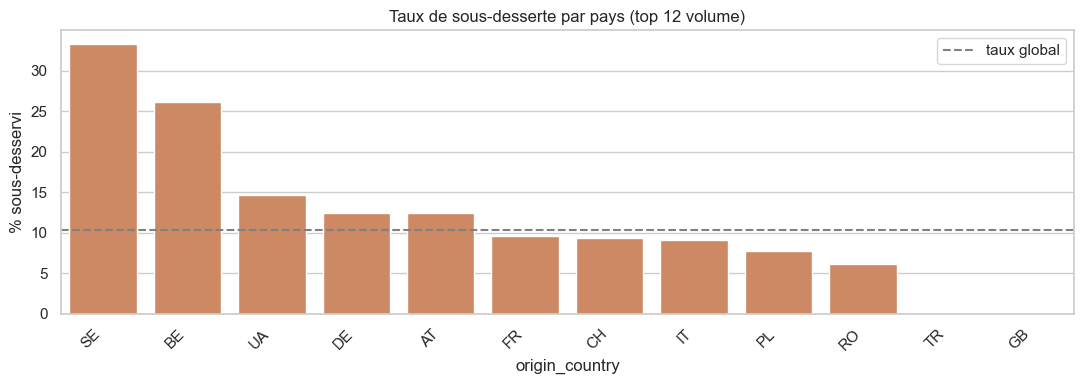

In [15]:
rate_country = (df.groupby('origin_country')['is_underserved'].mean()*100)
vol_country = df['origin_country'].value_counts()
geo = pd.DataFrame({'volume': vol_country, 'taux_sous_desserte_%': rate_country.round(1)}).sort_values('volume', ascending=False).head(12)
print(geo)

fig, ax = plt.subplots(figsize=(11, 4))
geo_sorted = geo.sort_values('taux_sous_desserte_%', ascending=False)
sns.barplot(x=geo_sorted.index, y=geo_sorted['taux_sous_desserte_%'], ax=ax, color='#dd8452')
ax.axhline(df.is_underserved.mean()*100, ls='--', color='grey', label='taux global')
ax.set_title('Taux de sous-desserte par pays (top 12 volume)'); ax.set_ylabel('% sous-desservi'); ax.legend()
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.savefig(PLOTS_DIR / 'eda_underserved_by_country.png', dpi=110); plt.show()

**Déduction §8** : le dataset est concentré sur l'Europe de l'Ouest (FR, DE, CH dominent). Les taux de sous-desserte varient par pays, mais certains pays ont de très faibles effectifs → estimations peu robustes.

## §9 — Synthèse & implications pour la modélisation

**Qualité** : données propres (0 manquant, 0 doublon), 3 678 lignes, 29 colonnes.

**Nettoyage recommandé** (pour `02_feature_engineering`) :
- supprimer les colonnes **constantes** (`train_gco2_pkm`, `plane_gco2_pkm`, etc.) et les colonnes **dupliquées** (`type` == `service_type`) ;
- les variables liées au CO₂ relèvent de l'**ancien sujet** → à écarter de la modélisation sous-desserte.

**Cible** : `is_underserved`, **binaire et déséquilibrée** (~10,4 % positifs).

**Point d'alerte majeur** : les features numériques cœur **n'expliquent pas la cible** (corrélations ≈ 0). Le signal exploitable est **faible** et surtout **catégoriel/géographique** (pays, opérateur, catégorie de distance).

**Conséquences** :
1. attentes réalistes : il sera **difficile de battre le baseline de 89,6 %** d'accuracy ;
2. **évaluation** : juger sur **recall/precision/F1 (classe 1)**, **ROC-AUC** et **PR-AUC**, pas l'accuracy ;
3. **modélisation** : encoder soigneusement les catégorielles, rééquilibrer les classes ;
4. **recommandation amont** : réexaminer la **définition / construction de `is_underserved`** et envisager d'enrichir les features (la sous-desserte « demande > offre » devrait logiquement dépendre de `load_factor`/`service_ratio`, ce qui n'est pas le cas ici).